# Dynamic Geographic Ratemaking under Tail Risk

### A Distributional Reinforcement Learning Framework for Dynamic Insurance Zoning

[![Python](https://img.shields.io/badge/Python-3.10%2B-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![PyTorch](https://img.shields.io/badge/PyTorch-Distributional_RL-EE4C2C?logo=pytorch&logoColor=white)](https://pytorch.org/)
[![CUDA](https://img.shields.io/badge/CUDA-Supported-76B900?logo=nvidia&logoColor=white)](https://developer.nvidia.com/cuda-toolkit)
[![Reproducible Research](https://img.shields.io/badge/Reproducible-Research-2EA44F)](#reproducibility)
[![Zenodo](https://img.shields.io/badge/Zenodo-10.5281%2Fzenodo.22826154-1682D4?logo=zenodo&logoColor=white)](https://doi.org/10.5281/zenodo.22826154)
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.22826154.svg)](https://doi.org/10.5281/zenodo.22826154)

---

## Overview

This repository contains the computational and reproducibility materials for the study:

> **Dynamic Geographic Ratemaking under Tail Risk: A Distributional Reinforcement Learning Approach**

The project studies dynamic geographic ratemaking as a finite-horizon sequential actuarial decision problem. Spatial risk information is converted into admissible geographic classifications and territorial pricing decisions, while policies are evaluated through their induced cumulative actuarial return distributions.

The computational framework distinguishes three objects that should not be conflated:

1. **statistical risk representation**, describing predecision spatial insurance risk;
2. **geographic and pricing decisions**, determining admissible territorial classifications and relativities;
3. **policy-level return distributions**, used to evaluate complete sequential policies.

The implementation combines geographic insurance zoning, tail-sensitive policy evaluation, and distributional reinforcement learning in a reviewer-auditable computational pipeline.

---

## Research Design

The pipeline implements a commune-level French calibrated actuarial environment and supports four empirical policy architectures:

| Policy | Return representation | Local decision rule | Policy-level selection |
|---|---|---|---|
| **Static Zoning** | Fixed geographic benchmark | Adaptive pricing only | Benchmark |
| **Mean DQN** | Scalar expected return | Mean based | Mean based |
| **QR Mean** | Quantile return distribution | Mean based | Mean based |
| **Tail-QR Zoning** | Quantile return distribution | Tail sensitive | Tail sensitive |

This design separates **distributional representation** from **decision and selection rules**. In particular, moving from Mean DQN to QR Mean changes the representation of policy-conditional returns while retaining mean-based ranking and selection. Moving from QR Mean to Tail-QR Zoning retains the quantile representation while introducing tail-sensitive ranking and policy selection.

The distributional recursion is used for policy-conditional return-law evaluation. It is **not** interpreted as a Bellman decomposition of the policy-level precommitment tail criterion.

---

## Actuarial Criterion

For a policy $\pi$, the computational analysis evaluates cumulative actuarial return over the finite horizon. Policy comparison combines expected cumulative return with the Tail Value at Risk of adverse cumulative return.

Conceptually,

$$
J_{\alpha,\lambda}^{\pi} = \mathbb{E}[G_0^\pi] - \lambda \, \mathrm{TVaR}_{\alpha}(-G_0^\pi)
$$

The baseline implementation uses:

* tail probability level: $\alpha = 0.95$;
* tail loading: $\lambda = 0.75$;
* discount factor: $\gamma = 0.97$;
* horizon: 5 years.

The tail functional is applied to the distribution of the **complete cumulative return**. Local action scores are used for candidate-policy construction and are not recursively aggregated as policy-level values of $J_{\alpha,\lambda}$.
The baseline implementation uses

- tail probability level: $\alpha = 0.95$;
- tail loading: $\lambda = 0.75$;
- discount factor: $\gamma = 0.97$;
- horizon: $5$ years.

The tail functional is applied to the distribution of the **complete cumulative return**. Local action scores are used for candidate-policy construction and are not recursively aggregated as policy-level values of $J_{\alpha,\lambda}$.

---

In [1]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

from matplotlib.ticker import (FormatStrFormatter, MultipleLocator, LogLocator, NullFormatter)

from sklearn.metrics import adjusted_rand_score

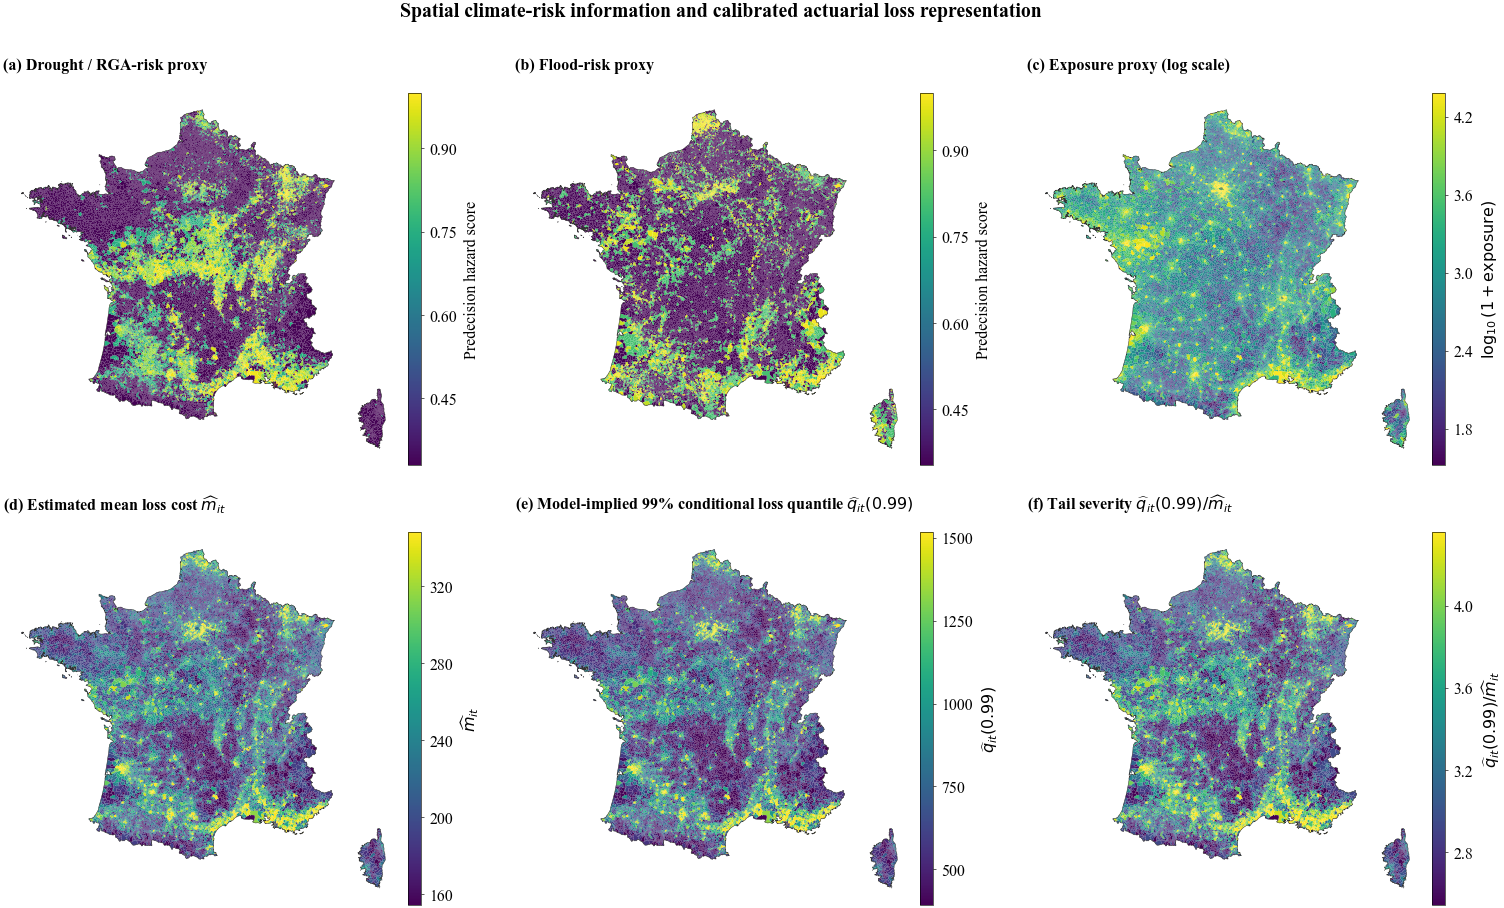

In [2]:
# ------------------------------------------------------------
# Figure 2
# ------------------------------------------------------------

CSV_FILE = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure2_climate_risk_atlas.csv")

GEOMETRY_FILE = Path("C:/Users/fredy/Downloads/Data_IME/raw/communes-100m.geojson.gz")

# Load figure data

df = pd.read_csv(CSV_FILE)


required_columns = ["code_commune", "rga_hazard", "flood_hazard", "exposure_proxy", "mhat", "qhat_0.99", "tail_mean_ratio"]


missing_columns = [col for col in required_columns if col not in df.columns]

# Normalize commune codes

df["code_commune"] = (df["code_commune"].astype(str).str.strip().str.upper().str.zfill(5))

for col in required_columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Load commune geometry

geo = gpd.read_file(f"/vsigzip/{GEOMETRY_FILE.resolve()}")

# Identify commune code column

candidate_code_columns = ["code", "CODE", "code_commune", "INSEE_COM", "code_insee", "id"]

code_column = None

for candidate in candidate_code_columns:

    if candidate in geo.columns:

        code_column = candidate

        break


if code_column is None:

    raise ValueError(
        "Could not identify commune code column. "
        f"Available columns: {list(geo.columns)}"
    )

geo = geo.rename(columns={code_column: "code_commune"})

geo["code_commune"] = (geo["code_commune"].astype(str).str.strip().str.upper().str.zfill(5))

# Metropolitan France only

department_code = geo["code_commune"].str[:2]

department_numeric = pd.to_numeric(department_code, errors="coerce")

mainland_mask = (department_numeric.between(1, 95))

corsica_mask = (department_code.isin(["2A", "2B"]))


geo = geo.loc[mainland_mask | corsica_mask].copy()

geo = geo.loc[geo.geometry.notna()].copy()

geo = geo.loc[~geo.geometry.is_empty].copy()


# ------------------------------------------------------------
# Project to Lambert-93
# ------------------------------------------------------------

if geo.crs is None:
    geo = geo.set_crs(4326)

geo = geo.to_crs(2154)

# Merge geometry and actuarial data

gdf = geo[["code_commune", "geometry"]].merge(df, on="code_commune", how="inner", validate="one_to_one",)

coverage = (len(gdf) / max(len(df), 1))


# Rename plotting variables

gdf["exposure"] = (gdf["exposure_proxy"])

gdf["qhat_99"] = (gdf["qhat_0.99"])

gdf["tail_to_mean"] = (gdf["tail_mean_ratio"])


# Clean non-finite values

plot_variables = [
    "rga_hazard",
    "flood_hazard",
    "exposure",
    "mhat",
    "qhat_99",
    "tail_to_mean",
]


for col in plot_variables:

    gdf[col] = pd.to_numeric(gdf[col], errors="coerce",)
    gdf.loc[~np.isfinite(gdf[col]),col] = np.nan

# ------------------------------------------------------------
# Display transformation for exposure
#
# Exposure is highly right-skewed.
# Only the map display is transformed.
# Original exposure remains unchanged.
# ------------------------------------------------------------

gdf["log10_exposure"] = np.log10(1.0 + gdf["exposure"].clip(lower=0.0))

# ------------------------------------------------------------
# Publication display limits
#
# Hazard scores:
#   natural scale
#
# Other quantities:
#   1st–99th percentile color normalization
# ------------------------------------------------------------

plot_limits = {}


# Drought / RGA-risk proxy
rga_values = gdf["rga_hazard"].dropna().to_numpy()


plot_limits["rga_hazard"] = (float(np.nanmin(rga_values)),
                             float(np.nanmax(rga_values)))

# Flood-risk proxy
flood_values = gdf["flood_hazard"].dropna().to_numpy()

plot_limits["flood_hazard"] = (float(np.nanmin(flood_values)),
                               float(np.nanmax(flood_values)))

# Log exposure
exp_values = gdf["log10_exposure"].dropna().to_numpy()

plot_limits["log10_exposure"] = (float(np.nanquantile(exp_values, 0.01)), float(np.nanquantile(exp_values,0.99)))

# Mean loss
mhat_values = gdf["mhat"].dropna().to_numpy()

plot_limits["mhat"] = (float(np.nanquantile(mhat_values,0.01)),
                       float(np.nanquantile(mhat_values,0.99)))

# q99
q99_values = gdf["qhat_99"].dropna().to_numpy()
plot_limits["qhat_99"] = (float(np.nanquantile(q99_values,0.01)),
                          float(np.nanquantile(q99_values,0.99)))
# Tail-to-mean
tail_values = gdf["tail_to_mean"].dropna().to_numpy()

plot_limits["tail_to_mean"] = (float(np.nanquantile(tail_values,0.01)),
                               float(np.nanquantile(tail_values,0.99)))

# Sanity check for plotting ranges

for variable in plot_limits:

    vmin, vmax = plot_limits[variable]

    if not np.isfinite(vmin):
        raise ValueError(f"Non-finite vmin for {variable}")

    if not np.isfinite(vmax):
        raise ValueError(f"Non-finite vmax for {variable}")

    if np.isclose(vmin, vmax):
        delta = max(abs(vmin) * 0.01, 1e-8)

        plot_limits[variable] = (vmin - delta, vmax + delta)

figure_data = gdf[["code_commune", "rga_hazard", "flood_hazard", "exposure", "log10_exposure", "mhat", "qhat_99", "tail_to_mean"]].copy()

display_metadata = pd.DataFrame(
    {"panel": ["a", "b", "c", "d", "e", "f", ],
     "variable": ["rga_hazard", "flood_hazard", "log10_exposure", "mhat", "qhat_99", "tail_to_mean",],
     "vmin": [plot_limits["rga_hazard"][0], plot_limits["flood_hazard"][0],
              plot_limits["log10_exposure"][0], plot_limits["mhat"][0],
              plot_limits["qhat_99"][0], plot_limits["tail_to_mean"][0]],
     "vmax": [plot_limits["rga_hazard"][1], plot_limits["flood_hazard"][1],
              plot_limits["log10_exposure"][1], plot_limits["mhat"][1],
              plot_limits["qhat_99"][1], plot_limits["tail_to_mean"][1]],
     "display_rule": ["observed range", "observed range", "log10(1+x), 1st-99th percentile",
                      "1st-99th percentile", "1st-99th percentile", "1st-99th percentile"],
    }
)

# Robust national outline

outline_geo = gdf[["geometry"]].copy()

outline_geo = outline_geo.loc[outline_geo.geometry.notna()].copy()

outline_geo = outline_geo.loc[~outline_geo.geometry.is_empty].copy()

outline_geo = outline_geo.loc[outline_geo.geometry.notna()].copy()

outline_geo = outline_geo.loc[~outline_geo.geometry.is_empty].copy()

invalid_geometry_mask = (~outline_geo.geometry.is_valid)

if invalid_geometry_mask.any():
    outline_geo.loc[invalid_geometry_mask, "geometry"] = (outline_geo.loc[invalid_geometry_mask,"geometry"].geometry.buffer(0))

national_outline_gs = None

try:
    national_outline = (outline_geo.geometry.union_all())

    national_outline_gs = (gpd.GeoSeries([national_outline], crs=gdf.crs))

except Exception as exc:

    print()
    print(
        "WARNING: national outline could not be constructed."
    )

    print(
        "The maps will still be produced without "
        "the decorative national boundary."
    )

    print(
        "GEOS message:",
        exc,
    )


# ------------------------------------------------------------
# Matplotlib publication settings
# ------------------------------------------------------------

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 11.3,
        "axes.titlesize": 11.,
        "axes.labelsize": 12.,
        "xtick.labelsize": 11.0,
        "ytick.labelsize": 11.0,
        "legend.fontsize": 11.5,
        "axes.linewidth": 0.6,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
    }
)


# Panel definitions

panel_variables = ["rga_hazard", "flood_hazard", "log10_exposure", "mhat", "qhat_99", "tail_to_mean"]


panel_titles = [
    r"(a) Drought / RGA-risk proxy",
    r"(b) Flood-risk proxy",
    r"(c) Exposure proxy (log scale)",
    r"(d) Estimated mean loss cost $\widehat{m}_{it}$",
    r"(e) Model-implied 99% conditional loss quantile "
    r"$\widehat{q}_{it}(0.99)$",
    r"(f) Tail severity "
    r"$\widehat{q}_{it}(0.99)/\widehat{m}_{it}$",
]


colorbar_labels = [
    "Predecision hazard score",
    "Predecision hazard score",
    r"$\log_{10}(1+\mathrm{exposure})$",
    r"$\widehat{m}_{it}$",
    r"$\widehat{q}_{it}(0.99)$",
    r"$\widehat{q}_{it}(0.99)/\widehat{m}_{it}$",
]


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16.1, 9.5),
    constrained_layout=False,
)


axes = axes.ravel()

fig.subplots_adjust(
    left=0.035,
    right=0.95,
    bottom=0.045,
    top=0.900,
    wspace=0.14,
    hspace=0.18,
)

cmap = (mpl.colormaps["viridis"].copy())

cmap.set_bad(color="0.92")


# Plot panels

for panel_index in range(6):
    ax = axes[panel_index]
    variable = panel_variables[panel_index]
    title = panel_titles[panel_index]
    cbar_label = colorbar_labels[panel_index]
    vmin, vmax = plot_limits[variable]

    norm = Normalize(
        vmin=vmin,
        vmax=vmax,
        clip=True,
    )

    gdf.plot(
        column=variable,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        missing_kwds={"color": "0.92", "edgecolor": "none",},
        rasterized=True,
        zorder=1,
    )

    if national_outline_gs is not None:
        national_outline_gs.boundary.plot(ax=ax, color="0.20", linewidth=0.35, zorder=3)

    ax.set_title(title,loc="left", fontsize=11.5, fontweight="semibold", pad=5.5)

    ax.set_aspect("equal")

    ax.set_axis_off()

    scalar_mappable = (mpl.cm.ScalarMappable(norm=norm, cmap=cmap))

    scalar_mappable.set_array([])

    cbar = fig.colorbar(
        scalar_mappable,
        ax=ax,
        orientation="vertical",
        fraction=0.030,
        pad=0.010,
        aspect=28,
    )

    cbar.ax.tick_params(
        labelsize=11.3,
        width=0.45,
        length=2.5,
        direction="out",
    )

    cbar.outline.set_linewidth(0.45)

    cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    cbar.set_label(
        cbar_label,
        fontsize=11.5,
        labelpad=5,
    )

fig.suptitle(
    "Spatial climate-risk information and calibrated actuarial loss representation",
    fontsize=14.2,
    fontweight="semibold",
    y=0.995,
)


plt.show()



FIGURE 3 — EMPIRICAL CHECKS
N communes                 : 34791
Static zones               : 96
Mean DQN zones             : 96
QR Mean zones              : 96
Tail-QR zones              : 96

ARI Static / Mean DQN      : 1.000000
ARI Static / QR Mean       : 1.000000
ARI Static / Tail-QR       : 1.000000
ARI QR Mean / Tail-QR      : 1.000000

Exact Static = Mean DQN    : True
Exact Static = QR Mean     : True
Exact Static = Tail-QR     : True

Mean DQN = Tail-QR tariff  : True
max |Mean DQN - QR Mean|   : 0.1560078339
mean |Mean DQN - QR Mean|  : 0.0117398275



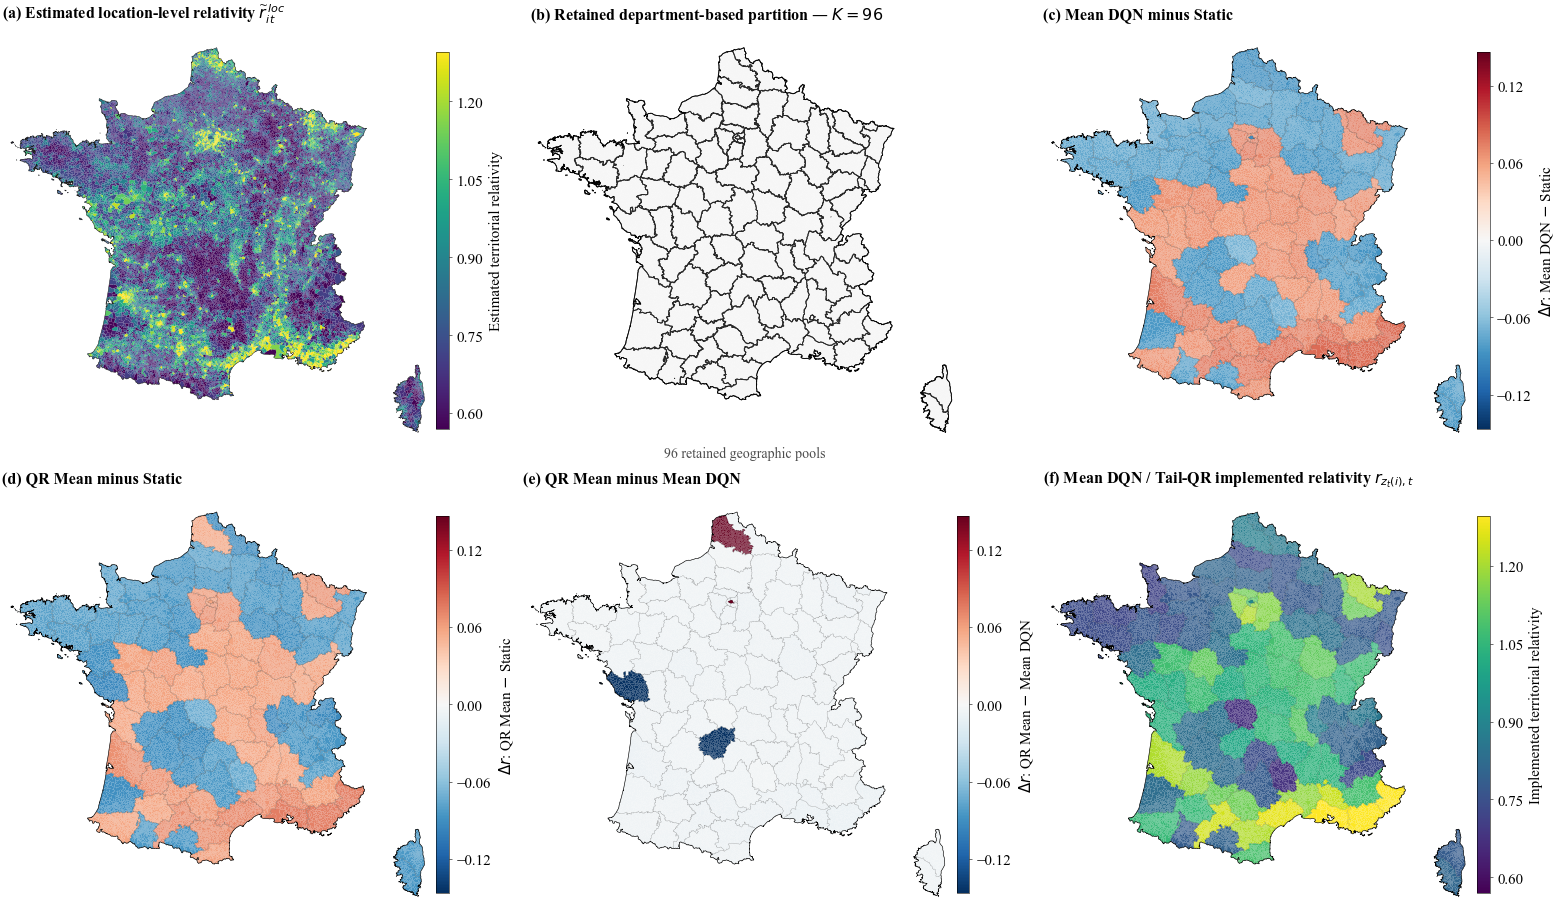

In [3]:
# ------------------------------------------------------------
# Figure 3
# ------------------------------------------------------------

CSV_FILE = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure3_implemented_zones.csv")

GEOMETRY_FILE = Path("C:/Users/fredy/Downloads/Data_IME/raw/communes-100m.geojson.gz")

df = pd.read_csv(CSV_FILE)


required_columns = [
    "code_commune",
    "mhat",
    "loc_rel",
    "zone_static_zoning",
    "rel_static_zoning",
    "zone_mean_dqn",
    "rel_mean_dqn",
    "zone_qr_mean",
    "rel_qr_mean",
    "zone_tail_qr_zoning",
    "rel_tail_qr_zoning",
]


missing_columns = [c for c in required_columns if c not in df.columns]

df["code_commune"] = (df["code_commune"].astype(str).str.strip().str.upper().str.zfill(5))


for c in required_columns:
    if c != "code_commune":
        df[c] = pd.to_numeric(df[c], errors="coerce")

ari_static_mean = adjusted_rand_score(df["zone_static_zoning"], df["zone_mean_dqn"])

ari_static_qr = adjusted_rand_score(df["zone_static_zoning"], df["zone_qr_mean"])

ari_static_tail = adjusted_rand_score(df["zone_static_zoning"], df["zone_tail_qr_zoning"])

ari_qr_tail = adjusted_rand_score(df["zone_qr_mean"], df["zone_tail_qr_zoning"])


exact_static_mean = bool(np.array_equal(df["zone_static_zoning"].to_numpy(), df["zone_mean_dqn"].to_numpy()))

exact_static_qr = bool(np.array_equal(df["zone_static_zoning"].to_numpy(), df["zone_qr_mean"].to_numpy()))

exact_static_tail = bool(np.array_equal(df["zone_static_zoning"].to_numpy(), df["zone_tail_qr_zoning"].to_numpy()))


# Terminal relativity diagnostics

mean_vs_qr_abs = (df["rel_mean_dqn"] - df["rel_qr_mean"]).abs()

mean_vs_tail_abs = (df["rel_mean_dqn"] - df["rel_tail_qr_zoning"]).abs()

mean_tail_identical = bool(np.allclose(df["rel_mean_dqn"], df["rel_tail_qr_zoning"],
                                       rtol=0.0, atol=1e-12))

print()
print("=" * 90)
print("FIGURE 3 — EMPIRICAL CHECKS")
print("=" * 90)

print(f"N communes                 : {len(df)}")
print(f"Static zones               : {df['zone_static_zoning'].nunique()}")
print(f"Mean DQN zones             : {df['zone_mean_dqn'].nunique()}")
print(f"QR Mean zones              : {df['zone_qr_mean'].nunique()}")
print(f"Tail-QR zones              : {df['zone_tail_qr_zoning'].nunique()}")

print()
print(f"ARI Static / Mean DQN      : {ari_static_mean:.6f}")
print(f"ARI Static / QR Mean       : {ari_static_qr:.6f}")
print(f"ARI Static / Tail-QR       : {ari_static_tail:.6f}")
print(f"ARI QR Mean / Tail-QR      : {ari_qr_tail:.6f}")

print()
print(f"Exact Static = Mean DQN    : {exact_static_mean}")
print(f"Exact Static = QR Mean     : {exact_static_qr}")
print(f"Exact Static = Tail-QR     : {exact_static_tail}")

print()
print(f"Mean DQN = Tail-QR tariff  : {mean_tail_identical}")
print(f"max |Mean DQN - QR Mean|   : {mean_vs_qr_abs.max():.10f}")
print(f"mean |Mean DQN - QR Mean|  : {mean_vs_qr_abs.mean():.10f}")

print("=" * 90)
print()

# Construct policy differences

df["delta_mean_vs_static"] = (df["rel_mean_dqn"] - df["rel_static_zoning"])

df["delta_qr_vs_static"] = (df["rel_qr_mean"] - df["rel_static_zoning"])

df["delta_qr_vs_mean"] = (df["rel_qr_mean"] - df["rel_mean_dqn"])

geo = gpd.read_file(f"/vsigzip/{GEOMETRY_FILE.resolve()}")

# Detect commune code column

candidate_code_columns = ["code", "CODE", "code_commune", "INSEE_COM", "code_insee", "id"]

code_column = None

for candidate in candidate_code_columns:
    if candidate in geo.columns:
        code_column = candidate
        break

if code_column is None:
    raise ValueError("Unable to identify commune code field.")

geo = geo.rename(columns={code_column: "code_commune"})

geo["code_commune"] = (geo["code_commune"].astype(str).str.strip().str.upper().str.zfill(5))


# Metropolitan France + Corsica

department_prefix = (geo["code_commune"].str[:2])

department_numeric = pd.to_numeric(department_prefix, errors="coerce")

mainland_mask = (department_numeric.between(1, 95))

corsica_mask = (department_prefix.isin(["2A", "2B"]))

geo = geo.loc[mainland_mask | corsica_mask].copy()

geo = geo.loc[geo.geometry.notna() & (~geo.geometry.is_empty)].copy()

# Project to Lambert-93

if geo.crs is None:
    geo = geo.set_crs(4326)

geo = geo.to_crs(2154)

#  Merge

gdf = geo[["code_commune", "departement", "geometry"]].merge(df, on="code_commune", how="inner", validate="one_to_one")

coverage = (len(gdf) / len(df))


zone_department_counts = (gdf.groupby("zone_static_zoning")["departement"].nunique())

department_zone_counts = (gdf.groupby("departement")["zone_static_zoning"].nunique())

zones_crossing_departments = int((zone_department_counts > 1).sum())

departments_split_across_zones = int((department_zone_counts > 1).sum())

department_partition_confirmed = (zones_crossing_departments == 0 and departments_split_across_zones == 0)

# Repair geometry COPY only for plotting boundaries

zone_geo = gdf.copy()

try:
    zone_geo["geometry"] = (zone_geo.geometry.make_valid())
except Exception:
    zone_geo["geometry"] = (zone_geo.geometry.buffer(0))

zone_geo = zone_geo.loc[zone_geo.geometry.notna() & (~zone_geo.geometry.is_empty)].copy()

invalid_mask = (~zone_geo.geometry.is_valid)


if invalid_mask.any():
    zone_geo.loc[invalid_mask,"geometry"] = (zone_geo.loc[invalid_mask, "geometry"].geometry.buffer(0))

# Department partition geometry

common_zones = (zone_geo[["zone_static_zoning", "geometry"]].dissolve(by="zone_static_zoning", as_index=False))

K_common = int(df["zone_static_zoning"].nunique())

# National outline

national_outline_gs = None

try:
    national_outline = (zone_geo.geometry.union_all())
    national_outline_gs = gpd.GeoSeries([national_outline], crs=gdf.crs)
except Exception as exc:
    print(
        "WARNING — national outline unavailable:",
        exc
    )

# Common geographic extent

xmin, ymin, xmax, ymax = (gdf.total_bounds)

xrange = xmax - xmin
yrange = ymax - ymin

xpad = 0.020 * xrange
ypad = 0.020 * yrange

common_xlim = (xmin - xpad, xmax + xpad)
common_ylim = (ymin - ypad, ymax + ypad)

# Common relativity scale
#
# Panels (a) and (f)

rel_values = np.concatenate([gdf["loc_rel"].to_numpy(float), gdf["rel_mean_dqn"].to_numpy(float)])

rel_values = rel_values[np.isfinite(rel_values)]


rel_vmin = float(np.quantile(rel_values,0.01))

rel_vmax = float(np.quantile(rel_values,0.99))

rel_norm = Normalize(vmin=rel_vmin, vmax=rel_vmax, clip=True)

# Common difference scale
#
delta_values = np.concatenate([gdf["delta_mean_vs_static"].to_numpy(float), gdf["delta_qr_vs_static"].to_numpy(float), gdf["delta_qr_vs_mean"].to_numpy(float)])

delta_values = delta_values[np.isfinite(delta_values)]

delta_lim = float(np.quantile(np.abs(delta_values),0.99))

if delta_lim <= 0:
    delta_lim = 0.01

delta_norm = TwoSlopeNorm(
    vmin=-delta_lim,
    vcenter=0.0,
    vmax=delta_lim
)

# Publication style

mpl.rcParams.update(
    {"font.family": "serif",
     "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
     "font.size": 11.8, "axes.titlesize": 11.5,
     "axes.labelsize": 10.2, "xtick.labelsize": 10.0, "ytick.labelsize": 10.0,
     "axes.linewidth": 0.5, "savefig.dpi": 600, "savefig.bbox": "tight", "savefig.pad_inches": 0.025
    }
)


# Figure

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16.1, 9.5),
    constrained_layout=False
)


axes = axes.ravel()


fig.subplots_adjust(
    left=0.025,
    right=0.95,
    bottom=0.04,
    top=0.95,
    wspace=0.16,
    hspace=0.16
)

# Colormaps

risk_cmap = (mpl.colormaps["viridis"].copy())

risk_cmap.set_bad(color="0.93")

diff_cmap = (mpl.colormaps["RdBu_r"].copy())

diff_cmap.set_bad(color="0.93")

# (a) Estimated location-level relativity

ax = axes[0]

gdf.plot(
    column="loc_rel",
    ax=ax,
    cmap=risk_cmap,
    norm=rel_norm,
    edgecolor="none",
    linewidth=0.0,
    rasterized=True,
    zorder=1
)


if national_outline_gs is not None:
    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.12",
        linewidth=0.35,
        zorder=4
    )

ax.set_title(
    r"(a) Estimated location-level relativity "
    r"$\widetilde r^{\,loc}_{it}$",
    loc="left",
    fontweight="semibold",
    pad=4
)


ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()

sm_a = mpl.cm.ScalarMappable(
    norm=rel_norm,
    cmap=risk_cmap
)

sm_a.set_array([])


cb_a = fig.colorbar(
    sm_a,
    ax=ax,
    fraction=0.028,
    pad=0.008,
    aspect=30
)

cb_a.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

cb_a.ax.tick_params(
    labelsize=11.1,
    width=0.4,
    length=2.0
)


cb_a.outline.set_linewidth(0.4)

cb_a.set_label(
    "Estimated territorial relativity",
    fontsize=10.9,
    labelpad=4
)


# ============================================================
# (b) Retained department-based partition
# ============================================================

ax = axes[1]

gdf.plot(
    ax=ax,
    color="0.965",
    edgecolor="none",
    rasterized=True,
    zorder=1
)

common_zones.boundary.plot(
    ax=ax,
    color="0.16",
    linewidth=0.65,
    zorder=3
)

if national_outline_gs is not None:

    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.02",
        linewidth=0.55,
        zorder=4
    )


ax.set_title(
    rf"(b) Retained department-based partition — $K={K_common}$",
    loc="left",
    fontweight="semibold",
    pad=4
)

ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()

# Small explanatory annotation instead of a meaningless colorbar

ax.text(
    0.50,
    -0.015,
    "96 retained geographic pools",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10.,
    color="0.30"
)

# ============================================================
# (c) Mean DQN minus Static
# ============================================================

ax = axes[2]

gdf.plot(
    column="delta_mean_vs_static",
    ax=ax,
    cmap=diff_cmap,
    norm=delta_norm,
    edgecolor="none",
    linewidth=0.0,
    rasterized=True,
    zorder=1
)

common_zones.boundary.plot(
    ax=ax,
    color="0.22",
    linewidth=0.13,
    alpha=0.45,
    zorder=3
)

if national_outline_gs is not None:

    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.02",
        linewidth=0.43,
        zorder=4
    )

ax.set_title(
    r"(c) Mean DQN minus Static",
    loc="left",
    fontweight="semibold",
    pad=4
)

ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()


sm_c = mpl.cm.ScalarMappable(
    norm=delta_norm,
    cmap=diff_cmap
)

sm_c.set_array([])

cb_delta = fig.colorbar(
    sm_c,
    ax=ax,
    fraction=0.028,
    pad=0.008,
    aspect=30
)

cb_delta.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

cb_delta.ax.tick_params(
    labelsize=10.8,
    width=0.4,
    length=2.0
)

cb_delta.outline.set_linewidth(0.4)

cb_delta.set_label(
    r"$\Delta r$: Mean DQN $-$ Static",
    fontsize=10.9,
    labelpad=4
)

# ============================================================
# (d) QR Mean minus Static
# ============================================================

ax = axes[3]

gdf.plot(
    column="delta_qr_vs_static",
    ax=ax,
    cmap=diff_cmap,
    norm=delta_norm,
    edgecolor="none",
    linewidth=0.0,
    rasterized=True,
    zorder=1
)

common_zones.boundary.plot(
    ax=ax,
    color="0.22",
    linewidth=0.13,
    alpha=0.45,
    zorder=3
)

if national_outline_gs is not None:

    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.02",
        linewidth=0.43,
        zorder=4
    )

ax.set_title(
    r"(d) QR Mean minus Static",
    loc="left",
    fontweight="semibold",
    pad=4
)

ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()


sm_d = mpl.cm.ScalarMappable(norm=delta_norm, cmap=diff_cmap)

sm_d.set_array([])

cb_delta = fig.colorbar(
    sm_d,
    ax=ax,
    fraction=0.028,
    pad=0.008,
    aspect=30
)

cb_delta.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

cb_delta.ax.tick_params(
    labelsize=10.8,
    width=0.4,
    length=2.0
)

cb_delta.outline.set_linewidth(0.4)

cb_delta.set_label(
    r"$\Delta r$: QR Mean $-$ Static",
    fontsize=10.8,
    labelpad=4
)

# ============================================================
# (e) QR Mean minus Mean DQN
# ============================================================

ax = axes[4]

gdf.plot(
    column="delta_qr_vs_mean",
    ax=ax,
    cmap=diff_cmap,
    norm=delta_norm,
    edgecolor="none",
    linewidth=0.0,
    rasterized=True,
    zorder=1
)

common_zones.boundary.plot(
    ax=ax,
    color="0.22",
    linewidth=0.13,
    alpha=0.45,
    zorder=3
)

if national_outline_gs is not None:

    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.02",
        linewidth=0.43,
        zorder=4
    )

ax.set_title(
    r"(e) QR Mean minus Mean DQN",
    loc="left",
    fontweight="semibold",
    pad=4
)

ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()

sm_e = mpl.cm.ScalarMappable(
    norm=delta_norm,
    cmap=diff_cmap
)

sm_e.set_array([])

cb_delta = fig.colorbar(
    sm_e,
    ax=ax,
    fraction=0.028,
    pad=0.008,
    aspect=30
)

cb_delta.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

cb_delta.ax.tick_params(
    labelsize=10.8,
    width=0.4,
    length=2.0
)

cb_delta.outline.set_linewidth(0.4)

cb_delta.set_label(
    r"$\Delta r$: QR Mean $-$ Mean DQN",
    fontsize=10.8,
    labelpad=4
)

# ============================================================
# (f) Mean DQN / Tail-QR implemented relativity
# ============================================================

ax = axes[5]

gdf.plot(
    column="rel_mean_dqn",
    ax=ax,
    cmap=risk_cmap,
    norm=rel_norm,
    edgecolor="none",
    linewidth=0.0,
    rasterized=True,
    zorder=1
)

common_zones.boundary.plot(
    ax=ax,
    color="0.20",
    linewidth=0.11,
    alpha=0.35,
    zorder=3
)


if national_outline_gs is not None:

    national_outline_gs.boundary.plot(
        ax=ax,
        color="0.02",
        linewidth=0.43,
        zorder=4
    )


ax.set_title(
    r"(f) Mean DQN / Tail-QR implemented relativity "
    r"$r_{z_t(i),t}$",
    loc="left",
    fontweight="semibold",
    pad=4
)


ax.set_xlim(common_xlim)
ax.set_ylim(common_ylim)
ax.set_aspect("equal")
ax.set_anchor("C")
ax.set_axis_off()


sm_f = mpl.cm.ScalarMappable(
    norm=rel_norm,
    cmap=risk_cmap
)

sm_f.set_array([])


cb_f = fig.colorbar(
    sm_f,
    ax=ax,
    fraction=0.028,
    pad=0.008,
    aspect=30
)


cb_f.ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

cb_f.ax.tick_params(
    labelsize=10.8,
    width=0.4,
    length=2.0
)

cb_f.outline.set_linewidth(0.4)

cb_f.set_label(
    "Implemented territorial relativity",
    fontsize=10.8,
    labelpad=4
)

plt.show()


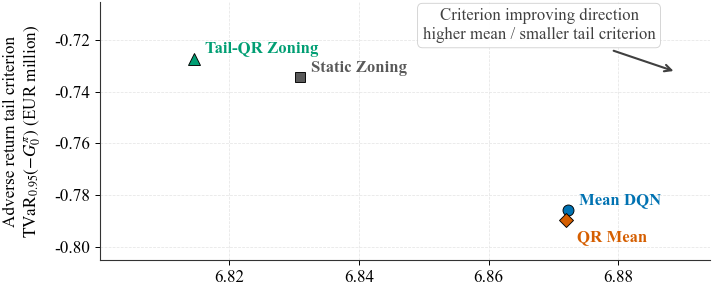

In [4]:
# ------------------------------------------------------------
# Figure 4'
# ------------------------------------------------------------


TABLE_FILE = "C:/Users/fredy/Downloads/Results_IME/csv_tables/table6_policy_performance.csv"

raw = pd.read_csv(TABLE_FILE)


ALPHA = 0.95
LAMBDA = 0.75

POLICIES = ["Static Zoning", "Mean DQN", "QR Mean", "Tail-QR Zoning",]

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 13.2,
    "axes.labelsize": 12.3,
    "xtick.labelsize": 12.3,
    "ytick.labelsize": 12.3,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "axes.unicode_minus": True,
})

required_columns = [
    "method",
    "stress",
    "mean_G0",
    "TVaR_alpha_adverse",
    "J_alpha_lambda",
    "n",
]

missing_columns = [c for c in required_columns if c not in raw.columns]


raw["method"] = (raw["method"].astype(str).str.strip())

raw["stress"] = (raw["stress"].astype(str).str.strip())


numeric_columns = ["mean_G0", "TVaR_alpha_adverse", "J_alpha_lambda", "n"]

for col in numeric_columns:
    raw[col] = pd.to_numeric(raw[col], errors="raise")

df = (raw.loc[raw["stress"].eq("historical"), required_columns].copy())


if df["method"].duplicated().any():
    duplicated = (df.loc[df["method"].duplicated(), "method"].tolist())

    raise ValueError(f"Duplicated historical policies: {duplicated}")

observed = set(df["method"])
expected = set(POLICIES)

missing = expected - observed
unexpected = observed - expected

df = (df.set_index("method").loc[POLICIES].copy())

df["J_reconstructed"] = (df["mean_G0"] - LAMBDA * df["TVaR_alpha_adverse"])

df["J_identity_error"] = (df["J_alpha_lambda"] - df["J_reconstructed"])


J_TOLERANCE_EUR = 1e-6


if not np.allclose(
    df["J_alpha_lambda"],
    df["J_reconstructed"],
    rtol=0.0,
    atol=J_TOLERANCE_EUR,
):
    diagnostics = df[["mean_G0", "TVaR_alpha_adverse", "J_alpha_lambda", "J_reconstructed", "J_identity_error"]]

    raise RuntimeError(
        "\nThe policy-performance file violates\n"
        "J = E[G_0] - lambda * TVaR_alpha(-G_0).\n\n"
        + diagnostics.to_string()
    )

N_TEST = int(df["n"].iloc[0])

diagnostics = df[
    ["mean_G0", "TVaR_alpha_adverse", "J_alpha_lambda", "J_reconstructed", "n"]].copy()

diagnostics["mean_G0"] /= 1e6
diagnostics["TVaR_alpha_adverse"] /= 1e6
diagnostics["J_alpha_lambda"] /= 1e6
diagnostics["J_reconstructed"] /= 1e6

diagnostics = diagnostics.rename(
    columns={
        "mean_G0": "Mean G0 (EUR M)",
        "TVaR_alpha_adverse": "TVaR (EUR M)",
        "J_alpha_lambda": "Reported J (EUR M)",
        "J_reconstructed": "Reconstructed J (EUR M)",
        "n": "n test",
    }
)

df["mean_million"] = (df["mean_G0"] / 1e6)

df["tail_million"] = (df["TVaR_alpha_adverse"] / 1e6)


colors = {
    "Static Zoning": "#595959",
    "Mean DQN": "#0072B2",
    "QR Mean": "#D55E00",
    "Tail-QR Zoning": "#009E73",
}

markers = {
    "Static Zoning": "s",
    "Mean DQN": "o",
    "QR Mean": "D",
    "Tail-QR Zoning": "^",
}

marker_sizes = {
    "Static Zoning": 7.5,
    "Mean DQN": 7.9,
    "QR Mean": 7.5,
    "Tail-QR Zoning": 8.5,
}

offsets = {
    "Static Zoning": (8, 6),
    "Mean DQN": (8, 7),
    "QR Mean": (8, -13),
    "Tail-QR Zoning": (8, 7),
}


# FIGURE

fig, ax = plt.subplots(figsize=(7.3, 3.3))

fig.subplots_adjust(
    left=0.14,
    right=0.975,
    bottom=0.175,
    top=0.955,
)

ax.set_axisbelow(True)

ax.grid(
    True,
    which="major",
    color="0.90",
    linewidth=0.55,
    linestyle="--",
    zorder=0,
)

for method in POLICIES:

    row = df.loc[method]

    ax.plot(
        row["mean_million"],
        row["tail_million"],
        marker=markers[method],
        markersize=marker_sizes[method],
        markerfacecolor=colors[method],
        markeredgecolor="black",
        markeredgewidth=0.65,
        linestyle="None",
        zorder=5,
    )

for method in POLICIES:
    row = df.loc[method]
    ax.annotate(
        method,
        xy=(row["mean_million"], row["tail_million"]),
        xytext=offsets[method],
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=12.1,
        fontweight="bold",
        color=colors[method],
        zorder=7
    )

x_min = df["mean_million"].min()
x_max = df["mean_million"].max()

y_min = df["tail_million"].min()
y_max = df["tail_million"].max()

x_span = x_max - x_min
y_span = y_max - y_min

ax.set_xlim(x_min - 0.25 * x_span, x_max + 0.38 * x_span,)

ax.set_ylim(y_min - 0.25 * y_span, y_max + 0.35 * y_span,)

ax.annotate(
    "Criterion improving direction\n"
    "higher mean / smaller tail criterion",
    xy=(0.945, 0.73),
    xycoords="axes fraction",
    xytext=(0.72, 0.91),
    textcoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color="0.25",
        shrinkA=6,
        shrinkB=2,
    ),
    ha="center",
    va="center",
    fontsize=12.1,
    color="0.25",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="0.80",
        linewidth=0.6,
        alpha=0.95,
    ),
    zorder=10,
)

ax.set_ylabel(
    "Adverse return tail criterion\n"
    r"$\mathrm{TVaR}_{0.95}(-G_0^\pi)$ (EUR million)",
    labelpad=8,
)

ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

ax.tick_params(axis="both", direction="out")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.spines["left"].set_color("0.20")
ax.spines["bottom"].set_color("0.20")


plt.show()



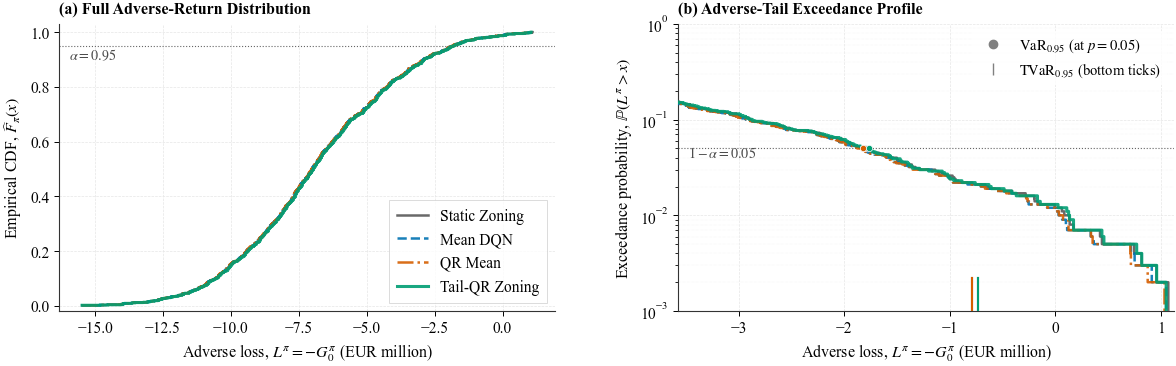

In [5]:
# ------------------------------------------------------------
# Figure 5
# ------------------------------------------------------------



import matplotlib.ticker as ticker

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11.3,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 11.2,
    "legend.fontsize": 11.2,
    "ytick.labelsize": 11.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.unicode_minus": True,
})


CSV_FILE_1 = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure5_tail_markers.csv")
CSV_FILE_2 = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure5_adverse_return_ecdf.csv")

expected_methods = ["Static Zoning", "Mean DQN", "QR Mean", "Tail-QR Zoning"]

try:
    markers_df = pd.read_csv(CSV_FILE_1)
    ecdf_df = pd.read_csv(CSV_FILE_2)
except FileNotFoundError:
    np.random.seed(42)
    ecdf_list = []
    markers_list = []

    for m in expected_methods:
        losses = np.random.gumbel(loc=5.0, scale=2.0, size=5000)
        ecdf_list.append(pd.DataFrame({
            "method": m,
            "adverse_return": losses
        }))
        var_val = np.quantile(losses, 0.95)
        tvar_val = losses[losses >= var_val].mean()
        markers_list.append({
            "method": m,
            "VaR": var_val,
            "TVaR": tvar_val
        })
    ecdf_df = pd.concat(ecdf_list, ignore_index=True)
    markers_df = pd.DataFrame(markers_list)

markers_df["method"] = markers_df["method"].astype(str).str.strip()
ecdf_df["method"] = ecdf_df["method"].astype(str).str.strip()

markers_df = markers_df.set_index("method").loc[expected_methods].reset_index()

ecdf_df["adverse_million"] = ecdf_df["adverse_return"] / 1e6
markers_df["VaR_million"] = markers_df["VaR"] / 1e6
markers_df["TVaR_million"] = markers_df["TVaR"] / 1e6

colors = {
    "Static Zoning": "#595959",
    "Mean DQN": "#0072B2",
    "QR Mean": "#D55E00",
    "Tail-QR Zoning": "#009E73",
}

linestyles = {
    "Static Zoning": "-",
    "Mean DQN": "--",
    "QR Mean": "-.",
    "Tail-QR Zoning": "-",
}

linewidths = {
    "Static Zoning": 1.8,
    "Mean DQN": 1.8,
    "QR Mean": 1.8,
    "Tail-QR Zoning": 2.2,
}

alpha = 0.95

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(11.8, 3.7),
    gridspec_kw={"width_ratios": [1.1, 1.1], "wspace": 0.1},
    layout="constrained"
)

# ------------------------------------------------------------
# PANEL (a) : FULL ECDF
# ------------------------------------------------------------
for method in expected_methods:
    x = ecdf_df.loc[ecdf_df["method"] == method, "adverse_million"].sort_values().to_numpy()
    n = len(x)
    F = np.arange(1, n + 1, dtype=float) / n

    ax1.step(
        x, F,
        where="post",
        color=colors[method],
        linestyle=linestyles[method],
        linewidth=linewidths[method],
        alpha=0.9,
        label=method,
        zorder=3
    )

ax1.axhline(alpha, color="0.4", linestyle=":", linewidth=0.8, zorder=1)
ax1.text(
    0.02, alpha - 0.05, r"$\alpha = 0.95$",
    transform=ax1.get_yaxis_transform(),
    fontsize=10.2, color="0.3", ha="left"
)

ax1.set_xlabel(r"Adverse loss, $L^\pi = -G_0^\pi$ (EUR million)")
ax1.set_ylabel(r"Empirical CDF, $\widehat{F}_\pi(x)$")
ax1.set_ylim(-0.02, 1.03)
ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax1.grid(True, linestyle="--", linewidth=0.5, color="0.9", zorder=0)
ax1.set_axisbelow(True)
ax1.set_title("(a) Full Adverse-Return Distribution", loc="left", fontweight="bold", pad=8)

# ------------------------------------------------------------
# PANEL (b) : SURVIVAL FUNCTION (LOG SCALE TAIL)
# ------------------------------------------------------------
for method in expected_methods:
    x = ecdf_df.loc[ecdf_df["method"] == method, "adverse_million"].sort_values().to_numpy()
    n = len(x)
    survival = (n - np.arange(1, n + 1, dtype=float)) / n
    pos = survival > 0
    ax2.step(
        x[pos], survival[pos],
        where="post",
        color=colors[method],
        linestyle=linestyles[method],
        linewidth=linewidths[method],
        alpha=0.9,
        zorder=3
    )

ax2.axhline(1.0 - alpha, color="0.4", linestyle=":", linewidth=0.8, zorder=1)
ax2.text(
    0.02, (1.0 - alpha) * 0.8, r"$1-\alpha = 0.05$",
    transform=ax2.get_yaxis_transform(),
    fontsize=10.2, color="0.3", ha="left"
)

for method in expected_methods:
    row = markers_df.loc[markers_df["method"] == method].iloc[0]
    ax2.plot(
        float(row["VaR_million"]), 1.0 - alpha,
        marker="o", markersize=4.5,
        markerfacecolor=colors[method],
        markeredgecolor="white", markeredgewidth=0.5,
        zorder=5
    )

y_min_tail, y_max_tail = 1e-3, 1.0
ax2.set_yscale("log")
ax2.set_ylim(y_min_tail, y_max_tail)

ax2.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

for i, method in enumerate(expected_methods):
    row = markers_df.loc[markers_df["method"] == method].iloc[0]
    tvar_x = float(row["TVaR_million"])
    ax2.plot(
        [tvar_x, tvar_x], [y_min_tail, y_min_tail * 2.2],
        color=colors[method], linewidth=1.5, zorder=6
    )

pooled = ecdf_df["adverse_million"].to_numpy()
x_tail_start = np.quantile(pooled, 0.85)
x_tail_end = np.max(pooled) * 1.02
ax2.set_xlim(x_tail_start, x_tail_end)

ax2.set_xlabel(r"Adverse loss, $L^\pi = -G_0^\pi$ (EUR million)")
ax2.set_ylabel(r"Exceedance probability, $\mathbb{P}(L^\pi > x)$")
ax2.grid(True, which="major", linestyle="--", linewidth=0.5, color="0.9", zorder=0)
ax2.grid(True, which="minor", linestyle=":", linewidth=0.35, color="0.93", zorder=0)
ax2.set_axisbelow(True)
ax2.set_title("(b) Adverse-Tail Exceedance Profile", loc="left", fontweight="bold", pad=8)

ax2.plot([], [], marker="o", color="gray", linestyle="None", label=r"$\mathrm{VaR}_{0.95}$ (at $p=0.05$)")
ax2.plot([], [], marker="|", color="gray", markersize=8, linestyle="None", label=r"$\mathrm{TVaR}_{0.95}$ (bottom ticks)")
ax2.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10.5)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["left"].set_color("0.2")
    ax.spines["bottom"].set_color("0.2")
    ax.tick_params(axis="both", direction="out")

leg = ax1.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="0.8",
    fancybox=False,
    borderpad=0.5,
    handlelength=2.0
)
leg.get_frame().set_linewidth(0.6)

plt.show()



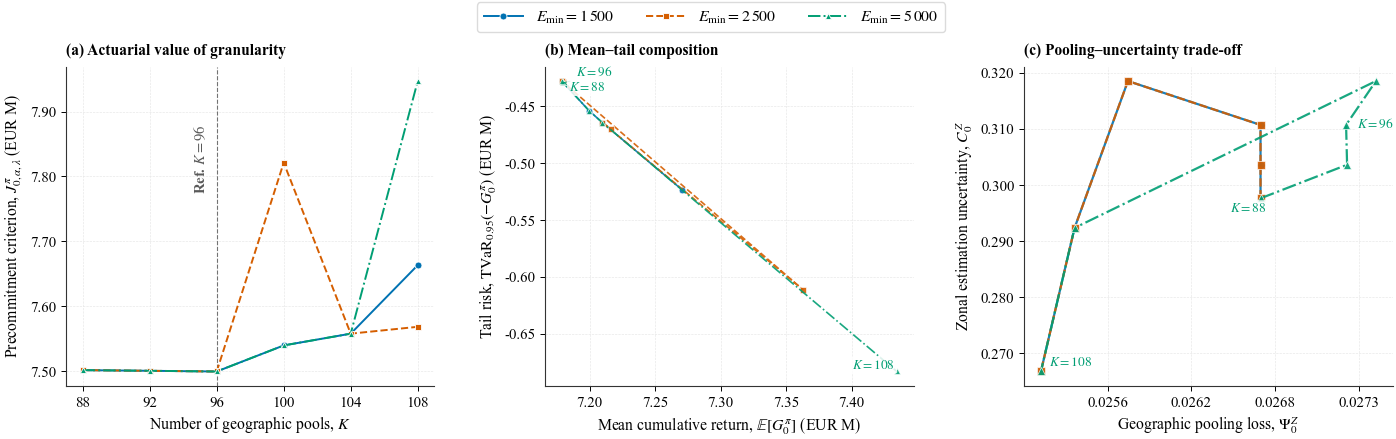

In [6]:
# ------------------------------------------------------------
# Figure 6
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12.0,
    "axes.labelsize": 11.3,
    "axes.titlesize": 11.2,
    "xtick.labelsize": 10.8,
    "ytick.labelsize": 10.8,
    "legend.fontsize": 11.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "axes.unicode_minus": False,
})

# ============================================================
CSV_FILE = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure6_granularity_frontier.csv")

df = pd.read_csv(CSV_FILE)

required_columns = ["E_min", "target_K", "K", "mean_G0", "TVaR_alpha_adverse", "J_alpha_lambda", "psi_z_t0", "uncertainty_t0", "n_mc", "frontier_type"]
df = df[required_columns].copy()

numeric_columns = ["E_min", "target_K", "K", "mean_G0", "TVaR_alpha_adverse", "J_alpha_lambda", "psi_z_t0", "uncertainty_t0", "n_mc"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="raise")

E_levels = sorted(df["E_min"].unique())
K_levels = sorted(df["K"].unique())

df["mean_G0_m"] = df["mean_G0"] / 1e6
df["TVaR_m"] = df["TVaR_alpha_adverse"] / 1e6
df["J_m"] = df["J_alpha_lambda"] / 1e6

colors = {1500.0: "#0072B2", 2500.0: "#D55E00", 5000.0: "#009E73"}
markers = {1500.0: "o", 2500.0: "s", 5000.0: "^"}
linestyles = {1500.0: "-", 2500.0: "--", 5000.0: "-."}

# FIGURE
fig, axes = plt.subplots(
    1, 3,
    figsize=(14.5, 4.5),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.0], "wspace": 0.3},
)

fig.subplots_adjust(
    left=0.055,
    right=0.97,
    bottom=0.150,
    top=0.860,
    wspace=0.28,
    hspace=0.20
)
ax1, ax2, ax3 = axes
reference_K = 96
handles_dict = {}

# ------------------------------------------------------------
# PANEL (a) : Actuarial value of granularity
# ------------------------------------------------------------
for E in E_levels:
    sub = df.loc[df["E_min"] == E].sort_values("K")
    val_str = f"{int(E):,}".replace(",", r"\,")
    label_text = rf"$E_{{\min}} = {val_str}$"

    line, = ax1.plot(
        sub["K"], sub["J_m"],
        color=colors[E], linestyle=linestyles[E], linewidth=1.4,
        marker=markers[E], markersize=5.0, markerfacecolor=colors[E],
        markeredgecolor="white", markeredgewidth=0.6,
        zorder=3
    )
    handles_dict[label_text] = line

ax1.axvline(reference_K, color="0.45", linestyle="--", linewidth=0.8, zorder=1)

ymin, ymax = ax1.get_ylim()
ax1.text(
    reference_K - 0.5,
    ymax - 0.18 * (ymax - ymin),
    r"Ref. $K=96$",
    fontsize=10.5, color="0.35", rotation=90,
    ha="right", va="top", fontweight="semibold"
)

ax1.set_xlabel(r"Number of geographic pools, $K$")
ax1.set_ylabel(r"Precommitment criterion, $J_{0,\alpha,\lambda}^{\pi}$ (EUR M)")
ax1.set_xticks(K_levels)
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax1.grid(True, linestyle="--", linewidth=0.45, color="0.90", zorder=0)
ax1.set_axisbelow(True)
ax1.set_title("(a) Actuarial value of granularity", loc="left", fontweight="bold", pad=8)

# ------------------------------------------------------------
# PANEL (b) : Mean–tail composition
# ------------------------------------------------------------
for E in E_levels:
    sub = df.loc[df["E_min"] == E].sort_values("K")
    ax2.plot(
        sub["mean_G0_m"], sub["TVaR_m"],
        color=colors[E], linestyle=linestyles[E], linewidth=1.2,
        marker=markers[E], markersize=4.8, markerfacecolor=colors[E],
        markeredgecolor="white", markeredgewidth=0.5, alpha=0.9, zorder=3
    )

sub_ref = df.loc[df["E_min"] == 5000.0].sort_values("K")

row_88 = sub_ref.loc[sub_ref["K"] == 88]
if not row_88.empty:
    r = row_88.iloc[0]
    ax2.annotate(
        r"$K=88$",
        xy=(r["mean_G0_m"], r["TVaR_m"]),
        xytext=(4, -6.2),
        textcoords="offset points",
        fontsize=9.5, fontweight="semibold", color=colors[5000.0],
        arrowprops=dict(arrowstyle="->", color=colors[5000.0], lw=0.6),
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        zorder=5
    )

row_96 = sub_ref.loc[sub_ref["K"] == 96]
if not row_96.empty:
    r = row_96.iloc[0]
    ax2.annotate(
        r"$K=96$",
        xy=(r["mean_G0_m"], r["TVaR_m"]),
        xytext=(10, 4),
        textcoords="offset points",
        fontsize=9.5, fontweight="semibold", color=colors[5000.0],
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        zorder=5
    )

row_108 = sub_ref.loc[sub_ref["K"] == 108]
if not row_108.empty:
    r = row_108.iloc[0]
    ax2.annotate(
        r"$K=108$",
        xy=(r["mean_G0_m"], r["TVaR_m"]),
        xytext=(-32, 2),
        textcoords="offset points",
        fontsize=9.5, fontweight="semibold", color=colors[5000.0],
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        zorder=5
    )

ax2.set_xlabel(r"Mean cumulative return, $\mathbb{E}[G_0^\pi]$ (EUR M)")
ax2.set_ylabel(r"Tail risk, $\mathrm{TVaR}_{0.95}(-G_0^\pi)$ (EUR M)")
ax2.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax2.grid(True, linestyle="--", linewidth=0.45, color="0.90", zorder=0)
ax2.set_axisbelow(True)
ax2.set_title("(b) Mean–tail composition", loc="left", fontweight="bold", pad=8)

# ------------------------------------------------------------
# PANEL (c) : Pooling–uncertainty trade-off
# ------------------------------------------------------------
for E in E_levels:
    sub = df.loc[df["E_min"] == E].sort_values("K")
    ax3.plot(
        sub["psi_z_t0"], sub["uncertainty_t0"],
        color=colors[E], linestyle=linestyles[E], linewidth=1.6,
        marker=markers[E], markersize=5.3, markerfacecolor=colors[E],
        markeredgecolor="white", markeredgewidth=0.5, alpha=0.9, zorder=3
    )

offsets_c = {
    88: (-22, -10),
    96: (8, -2),
    108: (6, 4),
}

for K_value in [88, 96, 108]:
    row = sub_ref.loc[sub_ref["K"] == K_value]
    if not row.empty:
        r = row.iloc[0]
        off = offsets_c.get(K_value, (4, 4))
        ax3.annotate(
            rf"$K={K_value}$",
            xy=(r["psi_z_t0"], r["uncertainty_t0"]),
            xytext=off, textcoords="offset points",
            fontsize=9.6, fontweight="semibold", color=colors[5000.0],
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=5
        )

ax3.set_xlabel(r"Geographic pooling loss, $\Psi_0^Z$")
ax3.set_ylabel(r"Zonal estimation uncertainty, $C_0^Z$")
ax3.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
ax3.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

psi_min, psi_max = df["psi_z_t0"].min(), df["psi_z_t0"].max()
if psi_max > psi_min:
    ax3.xaxis.set_major_locator(MultipleLocator((psi_max - psi_min) / 4.0))

ax3.grid(True, linestyle="--", linewidth=0.45, color="0.90", zorder=0)
ax3.set_axisbelow(True)
ax3.set_title("(c) Pooling–uncertainty trade-off", loc="left", fontweight="bold", pad=8)


for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["left"].set_color("0.20")
    ax.spines["bottom"].set_color("0.20")
    ax.tick_params(axis="both", direction="out")

fig.legend(
    handles=list(handles_dict.values()),
    labels=list(handles_dict.keys()),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="0.85",
    fontsize=11.4,
    handlelength=2.5,
    columnspacing=2.0
)

plt.show()




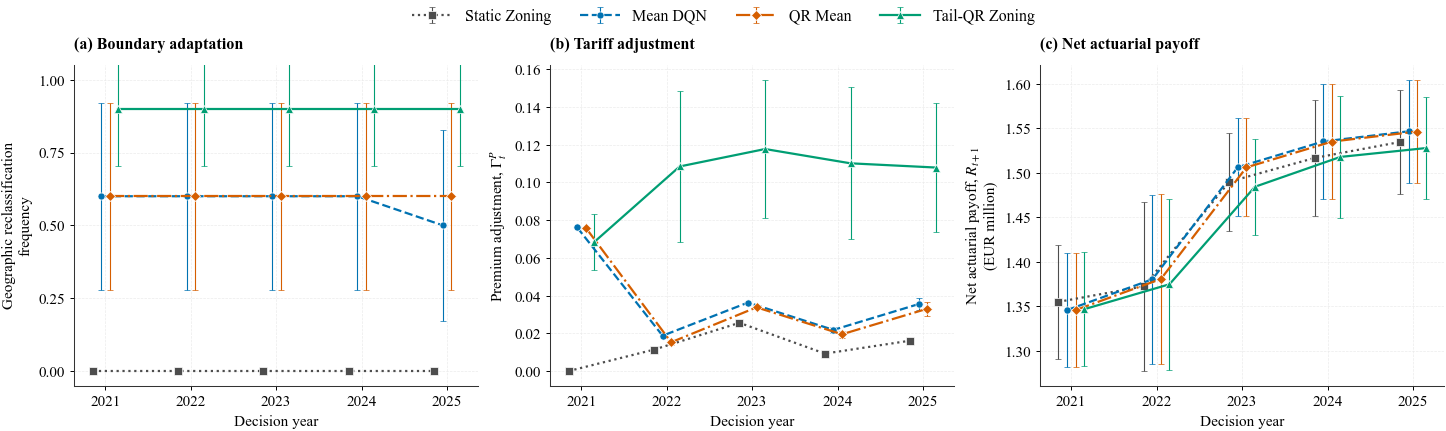

In [7]:
# ------------------------------------------------------------
# Figure 7
# ------------------------------------------------------------


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12.5,
    "axes.labelsize": 11.0,
    "axes.titlesize": 11.5,
    "xtick.labelsize": 11.0,
    "ytick.labelsize": 11.0,
    "legend.fontsize": 11.5,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": True,
})

CSV_FILE = Path("C:/Users/fredy/Downloads/Results_IME/csv_figures/figure7_dynamic_adaptation.csv")

df = pd.read_csv(CSV_FILE)

required_columns = [
    "trajectory_id", "method", "seed", "rep", "stress", "year",
    "action_id", "edit_type", "K", "underwriting_result", "reward",
    "discount", "psi_z", "psi_p", "c_zonal", "gamma_p", "z_delta", "decision_cost"
]

df["stress"] = df["stress"].astype(str).str.strip()
d = df.loc[df["stress"] == "historical"].copy()
d["method"] = d["method"].astype(str).str.strip()

methods = ["Static Zoning", "Mean DQN", "QR Mean", "Tail-QR Zoning"]

numeric_columns = [
    "seed", "rep", "year", "K", "underwriting_result", "reward",
    "discount", "psi_z", "psi_p", "c_zonal", "gamma_p", "z_delta", "decision_cost"
]

for col in numeric_columns:
    d[col] = pd.to_numeric(d[col], errors="raise")

years = sorted(d["year"].unique())

d["geographic_edit"] = d["edit_type"].astype(str).str.upper().ne("KEEP").astype(float)

seed_year = (
    d.groupby(["method", "seed", "year"], as_index=False)
    .agg(
        reclassification_rate=("geographic_edit", "mean"),
        premium_adjustment=("gamma_p", "mean"),
        zoning_turnover=("z_delta", "mean"),
        decision_cost=("decision_cost", "mean"),
        reward=("reward", "mean"),
        underwriting_result=("underwriting_result", "mean"),
        psi_z=("psi_z", "mean"),
    )
)


summary = (
    seed_year.groupby(["method", "year"], as_index=False)
    .agg(
        reclass_mean=("reclassification_rate", "mean"),
        reclass_sd=("reclassification_rate", "std"),
        reclass_n=("reclassification_rate", "count"),
        gamma_mean=("premium_adjustment", "mean"),
        gamma_sd=("premium_adjustment", "std"),
        turnover_mean=("zoning_turnover", "mean"),
        turnover_sd=("zoning_turnover", "std"),
        reward_mean=("reward", "mean"),
        reward_sd=("reward", "std"),
        decision_cost_mean=("decision_cost", "mean"),
        underwriting_mean=("underwriting_result", "mean"),
    )
)

summary["reclass_se"] = summary["reclass_sd"] / np.sqrt(summary["reclass_n"])
summary["gamma_se"] = summary["gamma_sd"] / np.sqrt(summary["reclass_n"])
summary["turnover_se"] = summary["turnover_sd"] / np.sqrt(summary["reclass_n"])
summary["reward_se"] = summary["reward_sd"] / np.sqrt(summary["reclass_n"])

summary["reward_mean_m"] = summary["reward_mean"] / 1e6
summary["reward_se_m"] = summary["reward_se"] / 1e6


# ============================================================
colors = {
    "Static Zoning": "#4D4D4D",
    "Mean DQN": "#0072B2",
    "QR Mean": "#D55E00",
    "Tail-QR Zoning": "#009E73",
}

markers = {
    "Static Zoning": "s",
    "Mean DQN": "o",
    "QR Mean": "D",
    "Tail-QR Zoning": "^",
}

linestyles = {
    "Static Zoning": ":",
    "Mean DQN": "--",
    "QR Mean": "-.",
    "Tail-QR Zoning": "-",
}

# Offsets visuels (Jittering) pour éviter la superposition des barres d'erreur
offsets = {
    "Static Zoning": -0.15,
    "Mean DQN": -0.05,
    "QR Mean": 0.05,
    "Tail-QR Zoning": 0.15,
}

# ============================================================
# FIGURE SIGNATURE
# ============================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(14.5, 4.3),
    sharex=True,
    layout="constrained"
)

fig.set_layout_engine("constrained", rect=[0, 0, 1, 0.93])

ax1, ax2, ax3 = axes

for method in methods:
    sub = summary.loc[summary["method"] == method].sort_values("year").copy()
    x_pos = sub["year"] + offsets[method]

    ax1.errorbar(
        x_pos, sub["reclass_mean"], yerr=1.96 * sub["reclass_se"],
        color=colors[method], linestyle=linestyles[method], linewidth=1.6,
        marker=markers[method], markersize=5.1, markerfacecolor=colors[method],
        markeredgecolor="white", markeredgewidth=0.5, ecolor=colors[method],
        elinewidth=0.8, capsize=2.0, capthick=0.8, label=method, zorder=3
    )

ax1.set_ylabel("Geographic reclassification\nfrequency")
ax1.set_ylim(-0.05, 1.05)
ax1.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax1.set_title("(a) Boundary adaptation", loc="left", fontweight="bold", pad=12)

for method in methods:
    sub = summary.loc[summary["method"] == method].sort_values("year").copy()
    x_pos = sub["year"] + offsets[method]

    ax2.errorbar(
        x_pos, sub["gamma_mean"], yerr=1.96 * sub["gamma_se"],
        color=colors[method], linestyle=linestyles[method], linewidth=1.6,
        marker=markers[method], markersize=5.2, markerfacecolor=colors[method],
        markeredgecolor="white", markeredgewidth=0.5, ecolor=colors[method],
        elinewidth=0.8, capsize=2.0, capthick=0.8, zorder=3
    )

ax2.set_ylabel(r"Premium adjustment, $\Gamma_t^P$")
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax2.set_title("(b) Tariff adjustment", loc="left", fontweight="bold", pad=12)

for method in methods:
    sub = summary.loc[summary["method"] == method].sort_values("year").copy()
    x_pos = sub["year"] + offsets[method]

    ax3.errorbar(
        x_pos, sub["reward_mean_m"], yerr=1.96 * sub["reward_se_m"],
        color=colors[method], linestyle=linestyles[method], linewidth=1.6,
        marker=markers[method], markersize=5.2, markerfacecolor=colors[method],
        markeredgecolor="white", markeredgewidth=0.5, ecolor=colors[method],
        elinewidth=0.8, capsize=2.0, capthick=0.8, zorder=3
    )

ax3.set_ylabel(r"Net actuarial payoff, $R_{t+1}$" "\n(EUR million)")
ax3.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax3.set_title("(c) Net actuarial payoff", loc="left", fontweight="bold", pad=12)

for ax in axes:
    ax.set_xlabel("Decision year")
    ax.set_xticks(years)
    ax.set_xticklabels([str(int(y)) for y in years])

    ax.grid(True, which="major", color="0.92", linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.75)
    ax.spines["bottom"].set_linewidth(0.75)
    ax.spines["left"].set_color("0.20")
    ax.spines["bottom"].set_color("0.20")
    ax.tick_params(axis="both", direction="out")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.50, 1.02),
    ncol=4,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.8
)

plt.show()


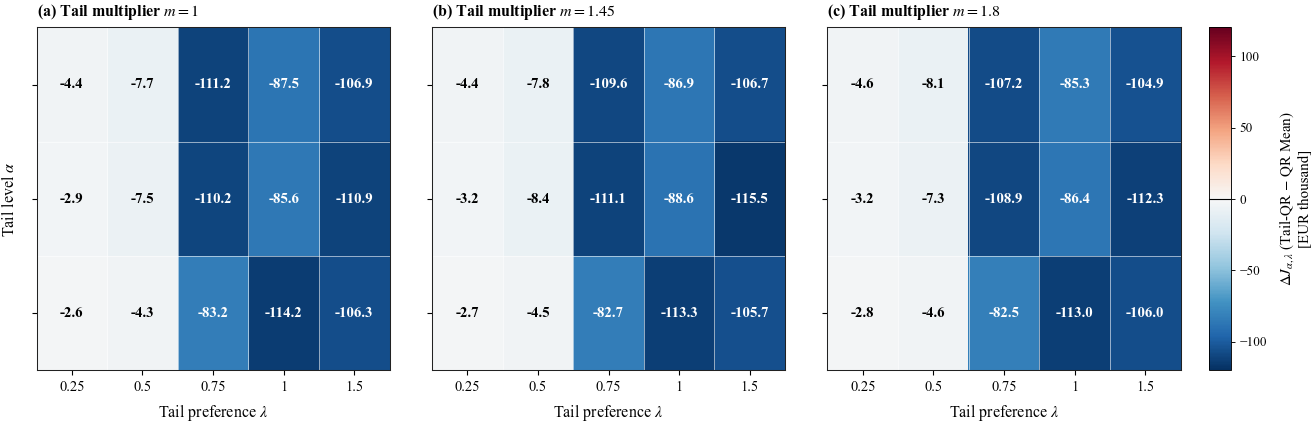

In [8]:
# ------------------------------------------------------------
# Figure 8
# ------------------------------------------------------------

CSV_FILE = Path(
    "C:/Users/fredy/Downloads/Results_IME/"
    "csv_figures/v13_phase_diagram.csv"
)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12.0,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8
})


df = pd.read_csv(CSV_FILE)

required_columns = [
    "alpha", "lambda", "tail_multiplier", "delta_mean_tail_minus_qr",
    "delta_tvar_tail_minus_qr", "delta_J_tail_minus_qr", "sd_delta_J",
    "tail_qr_win_rate", "n_seeds", "preferred_by_J"
]

df = df[required_columns].copy()

numeric_columns = [
    "alpha", "lambda", "tail_multiplier", "delta_mean_tail_minus_qr",
    "delta_tvar_tail_minus_qr", "delta_J_tail_minus_qr", "sd_delta_J",
    "tail_qr_win_rate", "n_seeds"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="raise")

alphas = np.sort(df["alpha"].unique())
lambdas = np.sort(df["lambda"].unique())
multipliers = np.sort(df["tail_multiplier"].unique())

duplicates = df.duplicated(subset=["alpha", "lambda", "tail_multiplier"], keep=False)

df["delta_J_kEUR"] = df["delta_J_tail_minus_qr"] / 1_000.0
df["sd_delta_J_kEUR"] = df["sd_delta_J"] / 1_000.0


max_abs = np.nanmax(np.abs(df["delta_J_kEUR"].to_numpy()))
color_limit = max_abs * 1.04
norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)
cmap = mpl.colormaps["RdBu_r"]

# Figure

fig, axes = plt.subplots(
    1, 3,
    figsize=(14.3, 4.9),
    sharey=True
)

fig.subplots_adjust(
    left=0.070,
    right=0.870,
    bottom=0.180,
    top=0.880,
    wspace=0.120
)

panel_letters = ["(a)", "(b)", "(c)"]
images = []

for panel_idx, multiplier in enumerate(multipliers):
    ax = axes[panel_idx]

    sub = df[np.isclose(df["tail_multiplier"], multiplier)].copy()
    pivot = sub.pivot(index="alpha", columns="lambda", values="delta_J_kEUR")
    pivot = pivot.reindex(index=alphas, columns=lambdas)
    matrix = pivot.to_numpy(dtype=float)

    im = ax.imshow(
        matrix,
        origin="lower",
        aspect="auto",
        interpolation="none",
        cmap=cmap,
        norm=norm,
        extent=[-0.5, len(lambdas) - 0.5, -0.5, len(alphas) - 0.5],
        rasterized=True,
        zorder=1
    )
    images.append(im)

    for x in np.arange(0.5, len(lambdas), 1.0):
        ax.axvline(x, color="white", linewidth=0.5, alpha=0.8, zorder=2)
    for y in np.arange(0.5, len(alphas), 1.0):
        ax.axhline(y, color="white", linewidth=0.5, alpha=0.8, zorder=2)

    for i in range(len(alphas)):
        for j in range(len(lambdas)):
            value = matrix[i, j]
            rgba = cmap(norm(value))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_color = "black" if luminance > 0.56 else "white"

            ax.text(
                j, i,
                f"{value:.1f}",
                ha="center", va="center",
                fontsize=10.7,
                fontweight="semibold",
                color=text_color,
                zorder=4
            )

    ax.set_xticks(np.arange(len(lambdas)))
    ax.set_xticklabels([f"{value:g}" for value in lambdas])
    ax.set_yticks(np.arange(len(alphas)))

    if panel_idx == 0:
        ax.set_yticklabels([f"{value:g}" for value in alphas])
        ax.set_ylabel(r"Tail level $\alpha$", labelpad=6)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel(r"Tail preference $\lambda$", labelpad=6)
    ax.set_title(
        f"{panel_letters[panel_idx]} Tail multiplier $m={multiplier:g}$",
        loc="left",
        fontweight="bold",
        pad=8
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color("#222222")

cax = fig.add_axes([0.890, 0.180, 0.015, 0.700])
cbar = fig.colorbar(images[0], cax=cax)

cbar.set_label(
    r"$\Delta J_{\alpha,\lambda}$ (Tail-QR $-$ QR Mean)" "\n" r"[EUR thousand]",
    fontsize=10.8,
    labelpad=8
)

cbar.ax.tick_params(labelsize=9.5, width=0.65, length=3.0)
cbar.outline.set_linewidth(0.65)

cbar.ax.axhline(0.0, color="black", linewidth=0.8, zorder=5)

plt.show()